# Initialize

In [ ]:
import requests
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import MobileBertConfig, MobileBertTokenizer, MobileBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Helper Function

In [2]:
def map_emotions_to_emoticon(emotions):
    emotion_map = {
        'admiration': '😊',
        'amusement': '😄',
        'anger': '😠',
        'annoyance': '😒',
        'approval': '👍',
        'caring': '🤗',
        'confusion': '😕',
        'curiosity': '🤔',
        'desire': '😍',
        'disappointment': '😞',
        'disapproval': '👎',
        'disgust': '🤢',
        'embarrassment': '😳',
        'excitement': '😁',
        'fear': '😨',
        'gratitude': '🙏',
        'grief': '😢',
        'joy': '😃',
        'love': '❤️',
        'nervousness': '😰',
        'optimism': '🌟',
        'pride': '🦚',
        'realization': '💡',
        'relief': '😌',
        'remorse': '😔',
        'sadness': '😭',
        'surprise': '😲',
        'neutral': '😐'
    }

    emoticons = [emotion_map.get(emotion, '') for emotion in emotions]
    return ' '.join(filter(None, emoticons))

# Baseline

In [4]:
# Load datasets
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
val_df = pd.read_csv('data/val.csv')

print("Dataset sizes:")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Validation: {val_df.shape}")

Dataset sizes:
Train: (4985, 30)
Test: (2230, 30)
Validation: (2178, 30)


In [30]:
# Separate features and labels
emotion_columns = train_df.columns[2:]  # All columns except 'text' and 'id'

X_train = train_df['text']
y_train = train_df[emotion_columns]

X_test = test_df['text']
y_test = test_df[emotion_columns]

X_val = val_df['text']
y_val = val_df[emotion_columns]

# Feature extraction - using both Count and TF-IDF
# We'll compare both to see which performs better
count_vectorizer = CountVectorizer(stop_words='english', min_df=2, max_features=5000)
tfidf_vectorizer = TfidfVectorizer(stop_words='english', min_df=2, max_features=5000)

# Transform the text data
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
X_val_counts = count_vectorizer.transform(X_val)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print(f"\nFeature dimensions:")
print(f"Count vectorizer features: {X_train_counts.shape[1]}")
print(f"TF-IDF vectorizer features: {X_train_tfidf.shape[1]}")

# Review class distribution
print("\nClass distribution in training set:")
for col in emotion_columns:
    pos_count = y_train[col].sum()
    total = len(y_train)
    print(f"{col}: {pos_count} positive instances ({pos_count/total:.4f})")


Feature dimensions:
Count vectorizer features: 3162
TF-IDF vectorizer features: 3162

Class distribution in training set:
admiration: 411 positive instances (0.0824)
amusement: 290 positive instances (0.0582)
anger: 290 positive instances (0.0582)
annoyance: 322 positive instances (0.0646)
approval: 372 positive instances (0.0746)
caring: 254 positive instances (0.0510)
confusion: 241 positive instances (0.0483)
curiosity: 296 positive instances (0.0594)
desire: 221 positive instances (0.0443)
disappointment: 317 positive instances (0.0636)
disapproval: 290 positive instances (0.0582)
disgust: 257 positive instances (0.0516)
embarrassment: 228 positive instances (0.0457)
excitement: 255 positive instances (0.0512)
fear: 266 positive instances (0.0534)
gratitude: 340 positive instances (0.0682)
grief: 143 positive instances (0.0287)
joy: 317 positive instances (0.0636)
love: 286 positive instances (0.0574)
nervousness: 248 positive instances (0.0497)
optimism: 328 positive instances (0

In [31]:
# Train Naive Bayes baseline models
# For multi-label classification with Naive Bayes
nb_count = MultiOutputClassifier(MultinomialNB(alpha=0.1))
nb_count.fit(X_train_counts, y_train)

nb_tfidf = MultiOutputClassifier(MultinomialNB(alpha=0.1))
nb_tfidf.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_count_test = nb_count.predict(X_test_counts)
y_pred_tfidf_test = nb_tfidf.predict(X_test_tfidf)

y_pred_count_val = nb_count.predict(X_val_counts)
y_pred_tfidf_val = nb_tfidf.predict(X_val_tfidf)

In [32]:
# Evaluate the models
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    # Calculate metrics
    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    accuracy = accuracy_score(y_true, y_pred)

    print(f"\nPerformance Metrics for {model_name} on {dataset_name} dataset:")
    print(f"Micro Precision: {precision_micro:.4f}")
    print(f"Micro Recall: {recall_micro:.4f}")
    print(f"Micro F1 Score: {f1_micro:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1 Score: {f1_macro:.4f}")
    print(f"Accuracy (Exact Match): {accuracy:.4f}")

    return {
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'accuracy': accuracy
    }

In [33]:
# Evaluate both models on test set
count_metrics_test = evaluate_model(y_test, y_pred_count_test, "Naive Bayes with Count Vectorizer", "test")
tfidf_metrics_test = evaluate_model(y_test, y_pred_tfidf_test, "Naive Bayes with TF-IDF Vectorizer", "test")

# Evaluate both models on validation set
count_metrics_val = evaluate_model(y_val, y_pred_count_val, "Naive Bayes with Count Vectorizer", "validation")
tfidf_metrics_val = evaluate_model(y_val, y_pred_tfidf_val, "Naive Bayes with TF-IDF Vectorizer", "validation")



Performance Metrics for Naive Bayes with Count Vectorizer on test dataset:
Micro Precision: 0.3346
Micro Recall: 0.1302
Micro F1 Score: 0.1875
Macro Precision: 0.2743
Macro Recall: 0.1198
Macro F1 Score: 0.1634
Accuracy (Exact Match): 0.0717

Performance Metrics for Naive Bayes with TF-IDF Vectorizer on test dataset:
Micro Precision: 0.5455
Micro Recall: 0.0339
Micro F1 Score: 0.0638
Macro Precision: 0.4196
Macro Recall: 0.0304
Macro F1 Score: 0.0533
Accuracy (Exact Match): 0.0305

Performance Metrics for Naive Bayes with Count Vectorizer on validation dataset:
Micro Precision: 0.3610
Micro Recall: 0.1260
Micro F1 Score: 0.1868
Macro Precision: 0.3148
Macro Recall: 0.1227
Macro F1 Score: 0.1714
Accuracy (Exact Match): 0.0762

Performance Metrics for Naive Bayes with TF-IDF Vectorizer on validation dataset:
Micro Precision: 0.6378
Micro Recall: 0.0359
Micro F1 Score: 0.0680
Macro Precision: 0.4259
Macro Recall: 0.0347
Macro F1 Score: 0.0616
Accuracy (Exact Match): 0.0321


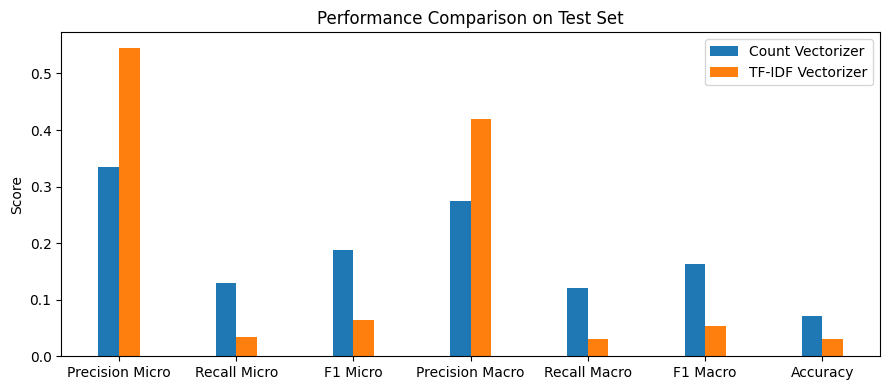

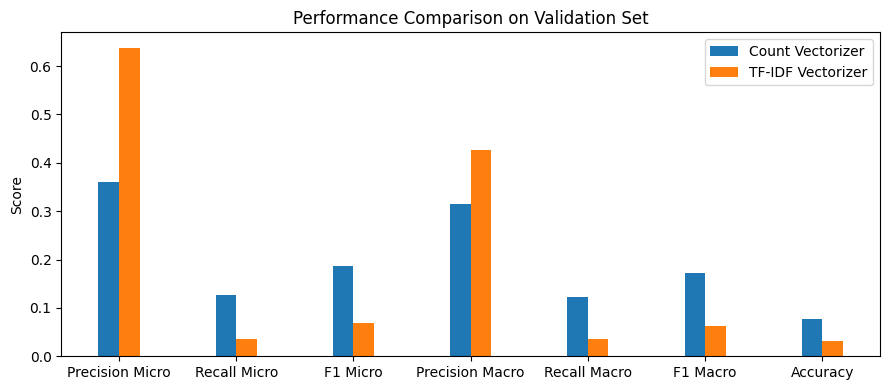

In [35]:
def plot_comparison(metrics_dict, title):
    models = list(metrics_dict.keys())
    metrics = ['precision_micro', 'recall_micro', 'f1_micro',
               'precision_macro', 'recall_macro', 'f1_macro', 'accuracy']

    fig, ax = plt.subplots(figsize=(9, 4))

    x = np.arange(len(metrics))
    width = 0.35 / len(models)

    for i, model in enumerate(models):
        values = [metrics_dict[model][m] for m in metrics]
        position = x + (i - len(models)/2 + 0.5) * width
        ax.bar(position, values, width, label=model)

    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
    ax.legend()

    plt.tight_layout()
    plt.show()

test_metrics = {
    'Count Vectorizer': count_metrics_test,
    'TF-IDF Vectorizer': tfidf_metrics_test
}
plot_comparison(test_metrics, 'Performance Comparison on Test Set')

val_metrics = {
    'Count Vectorizer': count_metrics_val,
    'TF-IDF Vectorizer': tfidf_metrics_val
}
plot_comparison(val_metrics, 'Performance Comparison on Validation Set')

In [46]:
def predict_emotions(text, vectorizer, model, emotion_labels):
    text_features = vectorizer.transform([text])
    predictions = model.predict(text_features)[0]
    predicted_emotions = [emotion_labels[i] for i, pred in enumerate(predictions) if pred == 1]

    return predicted_emotions

example_texts = test_df.loc[4:7,'text'].values.tolist()

print("\nExample Predictions:")
for text in example_texts:
    if count_metrics_val['f1_micro'] > tfidf_metrics_val['f1_micro']:
        emotions = predict_emotions(text, count_vectorizer, nb_count, emotion_columns)
        model_name = "Count Vectorizer"
    else:
        emotions = predict_emotions(text, tfidf_vectorizer, nb_tfidf, emotion_columns)
        model_name = "TF-IDF Vectorizer"

    emoticons = map_emotions_to_emoticon(emotions)

    print(f"\nText: '{text}'")
    print(f"Predicted emotions ({model_name}): {emotions}")
    print(f"Emoticons: {emoticons}")


Example Predictions:

Text: 'This is awesome. But also r/dontdeadopeninside'
Predicted emotions (Count Vectorizer): ['admiration']
Emoticons: 😊

Text: 'This is a very good point, which I hadn't thought of. Thanks dull!'
Predicted emotions (Count Vectorizer): ['gratitude']
Emoticons: 🙏

Text: 'Trier is low key an awful defender'
Predicted emotions (Count Vectorizer): ['fear']
Emoticons: 😨

Text: 'Sapa is pretty good, but Takashi is by far the best quality sushi in Salt Lake.'
Predicted emotions (Count Vectorizer): ['admiration', 'joy']
Emoticons: 😊 😃


# Main Model

In [12]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load datasets
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
val_df = pd.read_csv('data/val.csv')

# Extract emotion columns
emotion_columns = train_df.columns[2:]  # All columns except 'text' and 'id'

print(f"Total samples - Train: {len(train_df)}, Test: {len(test_df)}, Validation: {len(val_df)}")
print(f"Number of emotion labels: {len(emotion_columns)}")

Using device: cuda
Total samples - Train: 4985, Test: 2230, Validation: 2178
Number of emotion labels: 28


In [13]:
# Create dataset
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the text
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(label)
        }

In [14]:
# Load the tokenizer and configure the model
# Using pre-trained MobileBERT tokenizer instead of training from scratch
tokenizer = MobileBertTokenizer.from_pretrained('google/mobilebert-uncased')

# Configure for multi-label classification
config = MobileBertConfig.from_pretrained('google/mobilebert-uncased')
config.num_labels = len(emotion_columns)
config.problem_type = "multi_label_classification"

# Create model
model = MobileBertForSequenceClassification.from_pretrained(
    'google/mobilebert-uncased',
    config=config
)
# Move model to device
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MobileBertForSequenceClassification(
  (mobilebert): MobileBertModel(
    (embeddings): MobileBertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 512)
      (token_type_embeddings): Embedding(2, 512)
      (embedding_transformation): Linear(in_features=384, out_features=512, bias=True)
      (LayerNorm): NoNorm()
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): MobileBertEncoder(
      (layer): ModuleList(
        (0-23): 24 x MobileBertLayer(
          (attention): MobileBertAttention(
            (self): MobileBertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=512, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): MobileBertSelfOutput(
              (dense): Linear(in_fe

In [15]:
# Create datasets and dataloaders
train_texts = train_df['text'].tolist()
train_labels = train_df[emotion_columns].values.tolist()

val_texts = val_df['text'].tolist()
val_labels = val_df[emotion_columns].values.tolist()

test_texts = test_df['text'].tolist()
test_labels = test_df[emotion_columns].values.tolist()

train_dataset = EmotionDataset(train_texts, train_labels, tokenizer)
val_dataset = EmotionDataset(val_texts, val_labels, tokenizer)
test_dataset = EmotionDataset(test_texts, test_labels, tokenizer)

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)


In [16]:
# Define training parameters
epochs = 5
optimizer = AdamW(model.parameters(), lr=2e-5)

# Calculate total training steps
total_steps = len(train_dataloader) * epochs

# Create learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0.1 * total_steps,
    num_training_steps=total_steps
)

# Training function
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

# Evaluation function
def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            predictions.extend(torch.sigmoid(logits).cpu().numpy() > 0.5)
            true_labels.extend(labels.cpu().numpy())

    predictions = np.array(predictions).astype(int)
    true_labels = np.array(true_labels).astype(int)

    # Calculate metrics
    precision_micro = precision_score(true_labels, predictions, average='micro', zero_division=0)
    recall_micro = recall_score(true_labels, predictions, average='micro', zero_division=0)
    f1_micro = f1_score(true_labels, predictions, average='micro', zero_division=0)

    precision_macro = precision_score(true_labels, predictions, average='macro', zero_division=0)
    recall_macro = recall_score(true_labels, predictions, average='macro', zero_division=0)
    f1_macro = f1_score(true_labels, predictions, average='macro', zero_division=0)

    # Exact match accuracy (all labels must match)
    accuracy = accuracy_score(true_labels, predictions)

    return {
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'accuracy': accuracy
    }

In [17]:
# Training loop
training_stats = []
val_stats = []

for epoch in range(epochs):
    print(f"======== Epoch {epoch+1} / {epochs} ========")

    # Train
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)
    print(f"Average training loss: {avg_train_loss:.4f}")

    # Evaluate on validation set
    val_metrics = evaluate(model, val_dataloader, device)
    print(f"Validation metrics:")
    print(f"Micro Precision: {val_metrics['precision_micro']:.4f}")
    print(f"Micro Recall: {val_metrics['recall_micro']:.4f}")
    print(f"Micro F1: {val_metrics['f1_micro']:.4f}")
    print(f"Accuracy (Exact Match): {val_metrics['accuracy']:.4f}")

    training_stats.append(avg_train_loss)
    val_stats.append(val_metrics)

======== Epoch 1 / 5 ========
Average training loss: 544826.8211
Validation metrics:
Micro Precision: 0.8085
Micro Recall: 0.0109
Micro F1: 0.0215
Accuracy (Exact Match): 0.0064
======== Epoch 2 / 5 ========
Average training loss: 0.1847
Validation metrics:
Micro Precision: 0.6380
Micro Recall: 0.1128
Micro F1: 0.1918
Accuracy (Exact Match): 0.0721
======== Epoch 3 / 5 ========
Average training loss: 0.1626
Validation metrics:
Micro Precision: 0.6305
Micro Recall: 0.1700
Micro F1: 0.2678
Accuracy (Exact Match): 0.1212
======== Epoch 4 / 5 ========
Average training loss: 0.1515
Validation metrics:
Micro Precision: 0.6305
Micro Recall: 0.1754
Micro F1: 0.2745
Accuracy (Exact Match): 0.1249
======== Epoch 5 / 5 ========
Average training loss: 0.1451
Validation metrics:
Micro Precision: 0.6295
Micro Recall: 0.1863
Micro F1: 0.2875
Accuracy (Exact Match): 0.1290



Test Set Results:
Micro Precision: 0.6307
Micro Recall: 0.2001
Micro F1: 0.3038
Macro Precision: 0.5564
Macro Recall: 0.1963
Macro F1: 0.2564
Accuracy (Exact Match): 0.1283


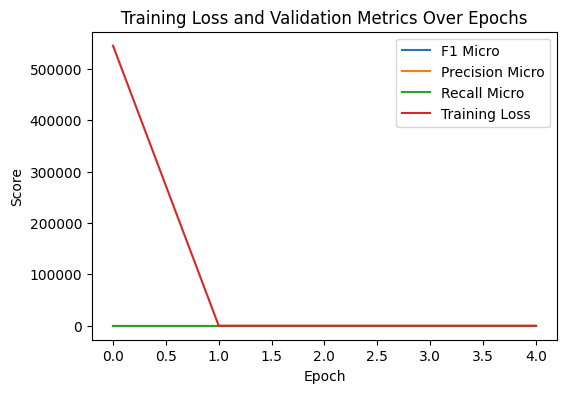

In [48]:
# Evaluate on test set
test_metrics = evaluate(model, test_dataloader, device)
print("\nTest Set Results:")
print(f"Micro Precision: {test_metrics['precision_micro']:.4f}")
print(f"Micro Recall: {test_metrics['recall_micro']:.4f}")
print(f"Micro F1: {test_metrics['f1_micro']:.4f}")
print(f"Macro Precision: {test_metrics['precision_macro']:.4f}")
print(f"Macro Recall: {test_metrics['recall_macro']:.4f}")
print(f"Macro F1: {test_metrics['f1_macro']:.4f}")
print(f"Accuracy (Exact Match): {test_metrics['accuracy']:.4f}")

# Plot training results
plt.figure(figsize=(6, 4))
plt.plot([m['f1_micro'] for m in val_stats], label='F1 Micro')
plt.plot([m['precision_micro'] for m in val_stats], label='Precision Micro')
plt.plot([m['recall_micro'] for m in val_stats], label='Recall Micro')
plt.plot(training_stats, label='Training Loss')
plt.title('Training Loss and Validation Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.savefig('mobilebert_training.png')
plt.show()

In [51]:
# Compare with baseline Naive Bayes results
print("\nComparison with Naive Bayes baseline:")
print("Metric\t\t\tMobileBERT\t\tNaive Bayes")
print(f"Micro F1:\t\t{test_metrics['f1_micro']:.4f}\t\t{count_metrics_test['f1_micro']:.4f}")
print(f"Micro Precision:\t{test_metrics['precision_micro']:.4f}\t\t{count_metrics_test['precision_micro']:.4f}")
print(f"Micro Recall:\t\t{test_metrics['recall_micro']:.4f}\t\t{count_metrics_test['recall_micro']:.4f}")
print(f"Accuracy:\t\t{test_metrics['accuracy']:.4f}\t\t{count_metrics_test['accuracy']:.4f}")


Comparison with Naive Bayes baseline:
Metric			MobileBERT		Naive Bayes
Micro F1:		0.3038		0.1875
Micro Precision:	0.6307		0.3346
Micro Recall:		0.2001		0.1302
Accuracy:		0.1283		0.0717


In [52]:
# Define prediction function for new texts
def predict_emotions(text, model, tokenizer, emotion_labels, threshold=0.3):
    model.eval()
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.sigmoid(logits).cpu().numpy()[0]

    predicted_emotions = [emotion_labels[i] for i, prob in enumerate(predictions) if prob > threshold]
    emotion_probs = {emotion_labels[i]: float(prob) for i, prob in enumerate(predictions)}

    return predicted_emotions, emotion_probs

# Example predictions
example_texts = example_texts = test_df.loc[4:7,'text'].values.tolist()

print("\nExample Predictions:")
for text in example_texts:
    predicted_emotions, emotion_probs = predict_emotions(text, model, tokenizer, emotion_columns, threshold=0.3)
    emoticons = map_emotions_to_emoticon(predicted_emotions)

    print(f"\nText: '{text}'")
    print(f"Predicted emotions: {predicted_emotions}")
    print(f"Top emotions with probabilities:")
    # Print top 3 emotions by probability
    top_emotions = sorted(emotion_probs.items(), key=lambda x: x[1], reverse=True)[:3]
    for emotion, prob in top_emotions:
        print(f"  {emotion}: {prob:.4f}")
    print(f"Emoticons: {emoticons}")




Example Predictions:

Text: 'This is awesome. But also r/dontdeadopeninside'
Predicted emotions: ['admiration']
Top emotions with probabilities:
  admiration: 0.3881
  joy: 0.2216
  excitement: 0.2073
Emoticons: 😊

Text: 'This is a very good point, which I hadn't thought of. Thanks dull!'
Predicted emotions: ['gratitude']
Top emotions with probabilities:
  gratitude: 0.9970
  admiration: 0.2375
  approval: 0.1677
Emoticons: 🙏

Text: 'Trier is low key an awful defender'
Predicted emotions: ['disgust']
Top emotions with probabilities:
  disgust: 0.4766
  fear: 0.2078
  annoyance: 0.1687
Emoticons: 🤢

Text: 'Sapa is pretty good, but Takashi is by far the best quality sushi in Salt Lake.'
Predicted emotions: ['approval']
Top emotions with probabilities:
  approval: 0.3207
  admiration: 0.2965
  love: 0.2432
Emoticons: 👍
